# Prague historical cycling connections

### Research question

**Research question.** Among mapped vanished path corridors in Prague, which ones would reduce modeled cycling route cost **if** a usable connection to the existing street network were provided, and how sensitive is the set of potentially connected corridors to the assumed maximum connection gap?

**Theoretical solution.** Represent the current streets as a directed, weighted graph $G_0$. For each historical corridor $i$, identify distinct possible access points to streets, then form a hypothetical graph $G_i$ containing that corridor and its access spurs. Compare shortest-path cost from population origins to destination sets under $G_0$ and $G_i$. A corridor has potential utility when this counterfactual reduces generalized route cost enough to pass a screening threshold.

**Study units.** The 1,178 source historical features are merged into 717 corridors; the corridor is the unit for connection screening and counterfactual scoring. The 57 Prague city parts are descriptive reporting units, not independent experimental subjects. The [interactive map](prague_graph_interactive.html) keeps all corridors visible, including those screened out.

## Study design

| Element | Operational definition |
|---|---|
| Baseline | Existing bicycle-access-screened street graph; planned cycling routes excluded |
| Intervention | Add one historical corridor at a time through its model-detected access points |
| Primary screening outcomes | Two or more active access points; generalized detour reduction; conditional population-weighted destination benefit |
| Robustness variable | Maximum permitted geometric access gap, examined at 0, 5, 10, 15 and 20 m |
| Descriptive stratifiers | Existing-road overlap, parallel alignment, major-road-crossing flag, intervention tier, city part |
| Decision gate | Crossing, land and cost review before project selection |

Two predictions guide the analysis: **P1**, many mapped historical lines will fail the two-access condition or duplicate an existing/parallel road; **P2**, allowing short proximity access will increase the model-routable count. We report counts, shares, quantiles and deterministic threshold sensitivity.

The modeled contrast is $d_{G_0}(o,k)-d_{G_i}(o,k)$: the change in shortest-path cost for origin $o$ and destination class $k$ when corridor $i$ is added. The following sections define the data, graph, connection rules and results.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == 'reports':
    ROOT = ROOT.parent
assert (ROOT / 'reports/corridor_screening_summary.csv').exists(), 'Run from the repository root or reports/'
read = lambda name: json.loads((ROOT / 'reports' / f'{name}.json').read_text(encoding='utf-8'))
inventory = read('analysis_summary')
graph = read('corrected_graph_summary')
graph_profile = read('graph_build_profile')
connections = read('corridor_connection_summary')
scoring = read('edge_connected_scoring_summary')
review = read('constructability_summary')
optimization = read('constructable_optimization_summary')
table = pd.read_csv(ROOT / 'reports/corridor_screening_summary.csv')
regional = pd.read_csv(ROOT / 'reports/regional_analysis_summary.csv')
sensitivity = pd.read_csv(ROOT / 'reports/connection_gap_sensitivity.csv')
transit = read('transit_context_summary')
transit_destinations = read('transit_destination_summary')
transit_corridors = pd.read_csv(ROOT / 'reports/transit_context_corridors.csv')
pd.set_option('display.max_columns', 20)

## 1. Data

| Input | Role | Provider / acquisition |
|---|---|---|
| Vanished paths | Candidate historical alignments, coarse ownership and cadastral hints | [IPR Prague open map item](https://mp.iprpraha.cz/portal/sharing/rest/content/items/80207f689893414b9429dbc032c96d79/data) |
| Streets and current cycling routes | Existing road graph and cycling-quality context | [Prague RÚIAN street service](https://mp.iprpraha.cz/arcgis/rest/services/ReferencedServices/RUIAN_Ulice_l/MapServer/0), [IPR cycling routes catalog](https://lkod.cz/catalog/praha/datasets/https%3A%2F%2Fapi.lkod.cz%2Flod%2F03bdf7d6-a255-4e22-83f9-4b17b6822602%2Fcatalog%2F5a9e58bd-615a-4c89-9f10-17d66f3daf6f) |
| Planned cycling network | Planning context only; excluded from the current-network baseline | [IPR cycling generel catalog](https://lkod.cz/catalog/praha/datasets/https%3A%2F%2Fapi.lkod.cz%2Flod%2F03bdf7d6-a255-4e22-83f9-4b17b6822602%2Fcatalog%2F299585fa-73cc-402c-a8bc-d8ea555953c4) |
| OSM Prague extract | Bicycle-access, road-class and bridge/tunnel screening | [Geofabrik Prague extract](https://download.geofabrik.de/europe/czech-republic/praha-latest.osm.pbf) |
| Terrain | Directional slope impedance | [ČÚZK DMR5G image service](https://ags.cuzk.cz/arcgis/rest/services/3D/dmr5g/ImageServer) |
| Population and zones | Origin weights | [Prague ZSJ boundaries](https://mp.iprpraha.cz/arcgis/rest/services/ReferencedServices/RUIAN_Zsj_p/MapServer/0), [ČSÚ SLDB 2021 Prague city-part data](https://csu.gov.cz/produkty/scitani-lidu-domu-a-bytu-hl-m-praha-analyza-vysledku-2021); input workbook in `data/raw/` |
| Train service | Identify train-served Prague stops used as destinations | [PID GTFS](https://data.pid.cz/PID_GTFS.zip) |
| PID route geometry | Descriptive proximity to service alignments | [PID lines catalog](https://lkod.cz/catalog/praha/datasets/https%3A%2F%2Fapi.lkod.cz%2Flod%2F03bdf7d6-a255-4e22-83f9-4b17b6822602%2Fcatalog%2F7a430e0e-eb8d-4039-b35e-57fd3a55c9c9) |
| Metro entrances | Metro access destinations and descriptive proximity | [IPR metro entrances catalog](https://lkod.cz/catalog/praha/datasets/https%3A%2F%2Fapi.lkod.cz%2Flod%2F03bdf7d6-a255-4e22-83f9-4b17b6822602%2Fcatalog%2F11068fe3-0a50-4df8-a703-0458a12478d0) |
| Cadastral map | Visual land-context review, not permission to build | [ČÚZK cadastral WMS](https://services.cuzk.gov.cz/wms/local-km-wms.asp) |

Source acquisition and analysis commands are documented separately in [`RUNNING.md`](../RUNNING.md). This report uses the published data snapshot.

In [2]:
inventory_table = pd.DataFrame([
    ['Historical source features', inventory['historical_paths']['features']],
    ['Historical source length (km)', inventory['historical_paths']['total_length_km']],
    ['City parts', inventory['boundaries']['city_parts']],
    ['ZSJ zones', inventory['boundaries']['zsj']],
    ['Population in city-part table', inventory['population']['total_population']],
    ['Corrected graph nodes', graph['nodes']],
    ['Corrected graph edges', graph['edges']],
], columns=['Measure', 'Value'])
inventory_table

,Measure,Value
0,Historical source features,1178.00
1,Historical source length (km),240.01
2,City parts,57.00
3,ZSJ zones,958.00
4,Population in city-part table,1301432.00
5,Corrected graph nodes,109905.00
6,Corrected graph edges,116100.00


### Input summary

The inventory below summarizes cleaned inputs. RÚIAN street features, current cycling-route features, and historical-path features have different mapping purposes and can overlap. Planned cycling routes are retained as context but excluded from the existing network. GTFS train stops and IPR metro entrances define the transport destinations. Population is allocated from city-part totals to smaller zones for the model.

All geometric lengths, offsets and buffers in the analysis use **S-JTSK / Krovak East North (EPSG:5514)**. The source layers are normalized before comparison; the map converts the results back to geographic coordinates for display. The compact reports preserve aggregate checks even when bulk source data is not checked into Git.

,Layer,Features,Mapped length (km)
0,RÚIAN street features,8070,3602.32
1,Existing cycling-route features,6328,1943.49
2,Planned cycling-route features,3224,1892.15
3,Historical path features,1178,240.01


,Check,Value
0,Historical features flagged in planned network,78
1,Historical features tagged city-owned,644
2,ZSJ origin zones,958
3,GTFS stops in source,19207


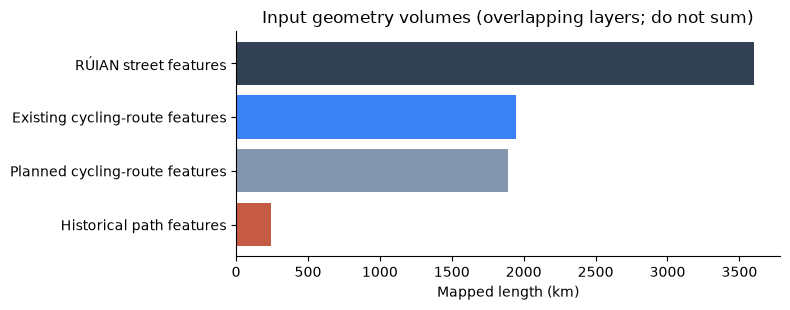

In [3]:
source_metrics = pd.DataFrame([
    ['RÚIAN street features', inventory['network']['streets']['features'], inventory['network']['streets']['total_length_km']],
    ['Existing cycling-route features', inventory['network']['cycling_routes']['features'], inventory['network']['cycling_routes']['total_length_km']],
    ['Planned cycling-route features', inventory['network']['cycling_generel']['features'], inventory['network']['cycling_generel']['total_length_km']],
    ['Historical path features', inventory['historical_paths']['features'], inventory['historical_paths']['total_length_km']],
], columns=['Layer', 'Features', 'Mapped length (km)'])
display(source_metrics)
display(pd.DataFrame([
    ['Historical features flagged in planned network', inventory['historical_paths']['flagged_in_cycling_generel_count']],
    ['Historical features tagged city-owned', inventory['historical_paths']['owned_by_hmp_count']],
    ['ZSJ origin zones', inventory['boundaries']['zsj']],
    ['GTFS stops in source', inventory['gtfs']['stops']],
], columns=['Check', 'Value']))
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.barh(source_metrics.Layer[::-1], source_metrics['Mapped length (km)'][::-1], color=['#c55b45','#8496ad','#3b82f6','#334155'])
ax.set(xlabel='Mapped length (km)', title='Input geometry volumes (overlapping layers; do not sum)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

### Transit context

The PID geodata contain route **lines**, while the IPR layer records physical **metro entrances**. For each historical corridor, the analysis measures minimum planar distance to either geometry in EPSG:5514. PID line proximity is descriptive context. Metro entrances, together with train-served GTFS stops inside Prague, are also snapped to street-graph nodes within 200 m and used as distinct destinations in the benefit model.

,Measure,Count
0,PID route-line features,819
1,Distinct PID route IDs,819
2,Metro entrance points,341
3,Metro stations represented,58
4,Metro entrance destinations snapped,341
5,Train stop destinations snapped,47
6,Corridors within 50 m of a PID line,294
7,Corridors within 300 m of a metro entrance,3


,Distance threshold (m),PID line,Metro entrance
0,50,294,0
1,100,345,0
2,300,555,3
3,500,660,17
4,1000,716,51


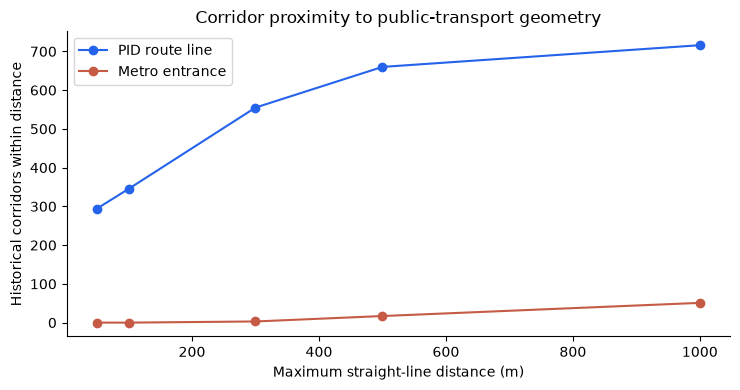

In [4]:
display(pd.DataFrame([
    ['PID route-line features', transit['pid_line_features']],
    ['Distinct PID route IDs', transit['pid_route_ids']],
    ['Metro entrance points', transit['metro_entrances']],
    ['Metro stations represented', transit['metro_stations']],
    ['Metro entrance destinations snapped', transit_destinations['metro_entrances_snapped']],
    ['Train stop destinations snapped', transit_destinations['train_stops_snapped']],
    ['Corridors within 50 m of a PID line', transit['corridors_near_pid_line_50m']],
    ['Corridors within 300 m of a metro entrance', transit['corridors_near_metro_entrance_300m']],
], columns=['Measure', 'Count']))
thresholds = [50, 100, 300, 500, 1000]
proximity = pd.DataFrame({
    'Distance threshold (m)': thresholds,
    'PID line': [(transit_corridors.nearest_pid_line_m <= m).sum() for m in thresholds],
    'Metro entrance': [(transit_corridors.nearest_metro_entrance_m <= m).sum() for m in thresholds],
})
display(proximity)
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(thresholds, proximity['PID line'], marker='o', label='PID route line', color='#2563eb')
ax.plot(thresholds, proximity['Metro entrance'], marker='o', label='Metro entrance', color='#c55b45')
ax.set(xlabel='Maximum straight-line distance (m)', ylabel='Historical corridors within distance',
       title='Corridor proximity to public-transport geometry')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

### City parts

The next table uses **57 Prague city parts** as reporting regions. Population is the source census city-part total. ZSJ-level population is an area-allocation estimate used to weight origin accessibility; it can differ from the city-part total, so the notebook shows both. A corridor is assigned to **one city part by its representative point** for a non-duplicated inventory count; this is not the same as the total length physically inside each boundary. Historical length is likewise attributed in full to that assigned city part. These are descriptive geographic summaries, not demand estimates for individual corridors.

For the neighboring-city-part comparison below, two parts are neighbors if their administrative polygons touch or lie within 10 m of one another. Each part's representative point is snapped to the nearest street-graph node, and shortest directed routes are measured to neighboring parts' representative points. Costs are generalized cycling metres divided by 250 m/min. Unreachable neighbors are counted separately.

In [5]:
display(regional[['city_part_name','population_total','corridors','model_routable_corridors',
                  'neighbor_count','reachable_neighbor_count','mean_neighbor_time_min']]
        .sort_values('population_total', ascending=False).round(2))
assert len(regional) == 57
assert int(regional.corridors.sum()) == connections['corridors']

,city_part_name,population_total,corridors,model_routable_corridors,neighbor_count,reachable_neighbor_count,mean_neighbor_time_min
16,Praha 4,130957,2.0,1.0,8,7,35.03
1,Praha 10,114377,0.0,0.0,8,0,NaN
20,Praha 8,104921,3.0,1.0,11,11,24.17
18,Praha 6,103254,39.0,11.0,11,10,38.48
17,Praha 5,89007,69.0,23.0,8,8,34.23
15,Praha 3,74307,0.0,0.0,4,3,19.24
2,Praha 11,72102,2.0,0.0,7,6,35.55
21,Praha 9,62651,0.0,0.0,6,5,22.28
4,Praha 13,60189,29.0,8.0,5,4,33.29
3,Praha 12,56591,58.0,15.0,4,3,35.75


### Corridors and population

The two aligned bars show **how many corridors** are assigned to each city part and **how many people live there**. They are sorted by corridor count. A corridor crossing city-part boundaries is counted once, where its representative point falls. Population is the city-part census total.

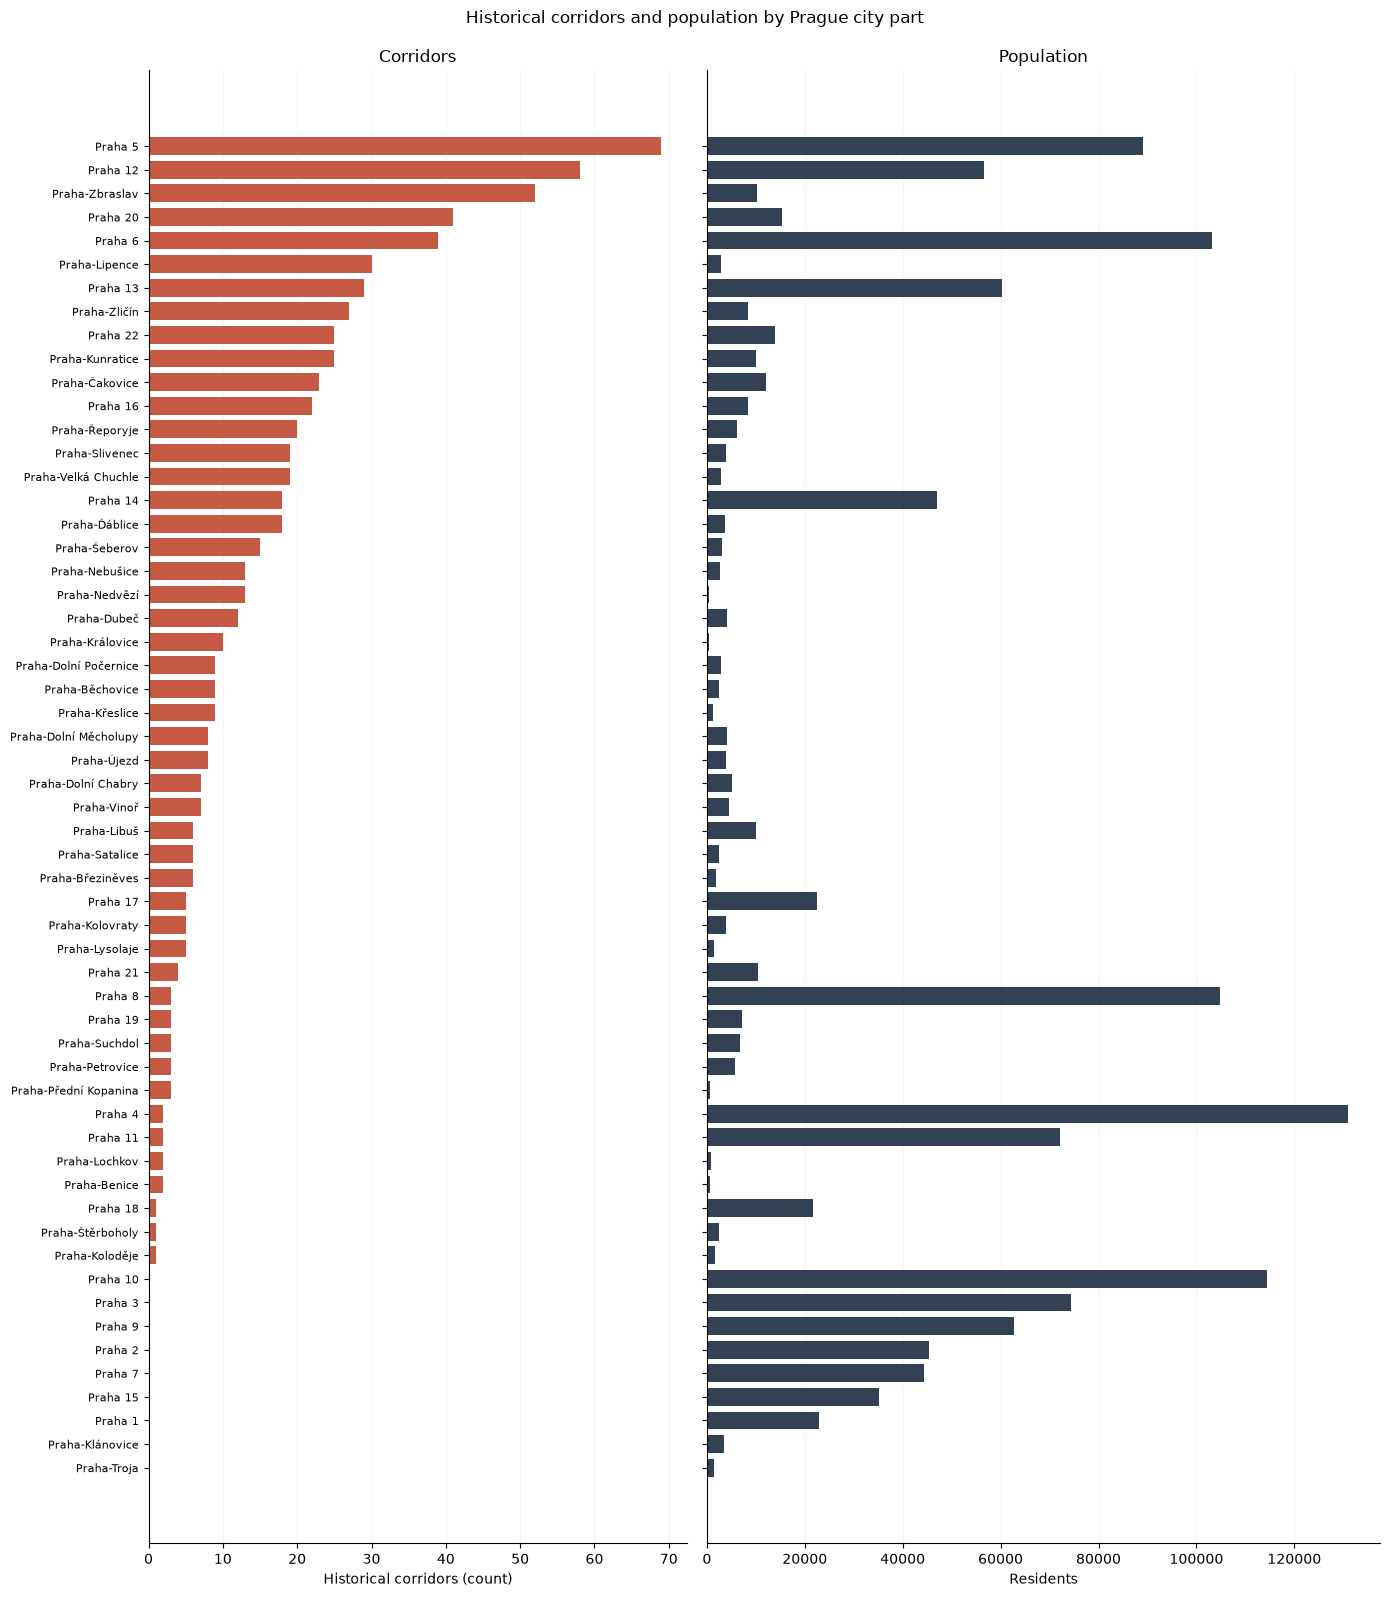

In [6]:
ordered = regional.sort_values(['corridors', 'population_total'], ascending=[True, True])
fig, (ax_count, ax_pop) = plt.subplots(1, 2, figsize=(14, 16), sharey=True,
                                     gridspec_kw={'width_ratios': [1, 1.25]})
y = np.arange(len(ordered))
ax_count.barh(y, ordered.corridors, color='#c55b45', height=.75)
ax_pop.barh(y, ordered.population_total, color='#334155', height=.75)
ax_count.set_yticks(y, ordered.city_part_name, fontsize=8)
ax_count.set(xlabel='Historical corridors (count)', title='Corridors')
ax_pop.set(xlabel='Residents', title='Population')
ax_pop.tick_params(axis='y', labelleft=False)
for ax in (ax_count, ax_pop):
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', alpha=.15)
    ax.set_axisbelow(True)
fig.suptitle('Historical corridors and population by Prague city part', y=.995)
plt.tight_layout(); plt.show()

### Neighboring city parts

The primary metric is **reachable neighbor share**:

$$R_i = \frac{\#\{j \in N(i): d_G(i,j) < \infty\}}{|N(i)|},$$

where $N(i)$ contains city parts whose polygons touch or lie within 10 m of city part $i$, and $d_G(i,j)$ is the shortest directed cycling cost between their representative points snapped to the current street graph. A neighbor counts as reachable when a finite route exists; there is **no travel-time cutoff**. Thus 100% means all adjacent parts are connected in the model, not that trips are short, safe or convenient. The companion table reports mean travel time among reachable neighbors and the count behind each share. No historical corridors are added.

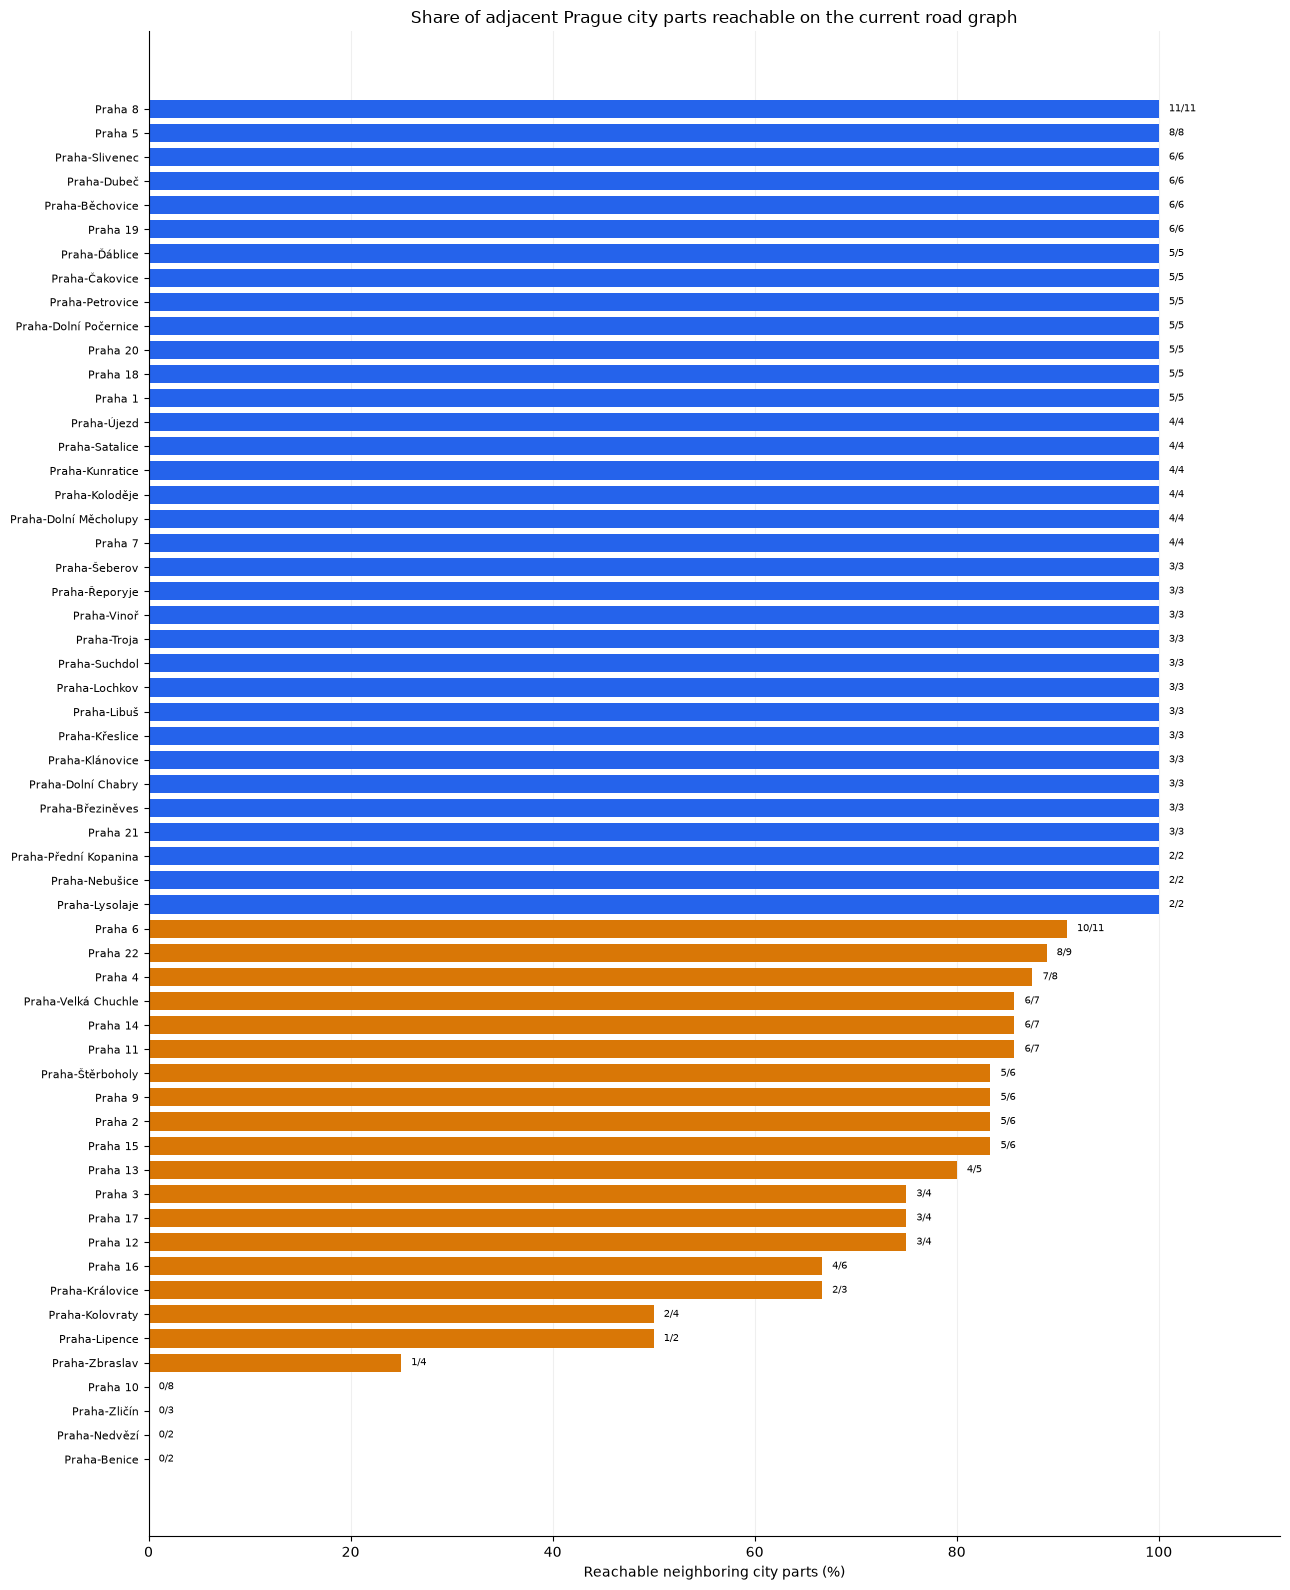

,city_part_name,neighbor_count,reachable_neighbor_count,reachable_neighbor_share,mean_neighbor_time_min,max_neighbor_time_min
1,Praha 10,8,0,0.00,NaN,NaN
22,Praha-Benice,2,0,0.00,NaN,NaN
50,Praha-Zličín,3,0,0.00,NaN,NaN
40,Praha-Nedvězí,2,0,0.00,NaN,NaN
49,Praha-Zbraslav,4,1,0.25,20.16,20.16
36,Praha-Lipence,2,1,0.50,21.18,21.18
31,Praha-Kolovraty,4,2,0.50,35.43,52.96
7,Praha 16,6,4,0.67,25.42,33.60
32,Praha-Královice,3,2,0.67,45.06,53.31
15,Praha 3,4,3,0.75,19.24,23.89


In [7]:
access_order = regional.sort_values(['reachable_neighbor_share', 'neighbor_count'], ascending=[True, True])
y = np.arange(len(access_order))
fig, ax = plt.subplots(figsize=(13, 16))
colors = np.where(access_order.reachable_neighbor_share.eq(1), '#2563eb', '#d97706')
ax.barh(y, 100 * access_order.reachable_neighbor_share, color=colors, height=.75)
for i, row in enumerate(access_order.itertuples()):
    ax.text(min(100 * row.reachable_neighbor_share + 1, 101), i,
            f'{int(row.reachable_neighbor_count)}/{int(row.neighbor_count)}', va='center', fontsize=7)
ax.set_yticks(y, access_order.city_part_name, fontsize=8)
ax.set(xlabel='Reachable neighboring city parts (%)', xlim=(0, 112),
       title='Share of adjacent Prague city parts reachable on the current road graph')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=.2)
ax.set_axisbelow(True)
plt.tight_layout(); plt.show()
display(regional[['city_part_name','neighbor_count','reachable_neighbor_count',
                  'reachable_neighbor_share','mean_neighbor_time_min','max_neighbor_time_min']]
        .sort_values('reachable_neighbor_share').round(2))

In [8]:
display(regional[['city_part_name','population_total','corridors','model_routable_corridors',
                  'major_crossing_candidates','neighbor_count','reachable_neighbor_count',
                  'mean_neighbor_time_min']]
        .sort_values('mean_neighbor_time_min', ascending=False).head(15).round(2))
print('City-part source population:', f'{regional.population_total.sum():,.0f}')
print('Corridors assigned:', f'{regional.corridors.sum():,.0f}')
print('Routable corridors assigned:', f'{regional.model_routable_corridors.sum():,.0f}')
print('City parts with at least one unreachable adjacent city part:',
      int(regional.reachable_neighbor_count.lt(regional.neighbor_count).sum()))

,city_part_name,population_total,corridors,model_routable_corridors,major_crossing_candidates,neighbor_count,reachable_neighbor_count,mean_neighbor_time_min
55,Praha-Šeberov,3179,15.0,3.0,4.0,3,3,54.17
32,Praha-Královice,438,10.0,0.0,0.0,3,2,45.06
51,Praha-Újezd,3829,8.0,0.0,0.0,4,4,41.24
18,Praha 6,103254,39.0,11.0,5.0,11,10,38.48
8,Praha 17,22461,5.0,1.0,0.0,4,3,36.40
3,Praha 12,56591,58.0,15.0,20.0,4,3,35.75
34,Praha-Křeslice,1173,9.0,1.0,1.0,3,3,35.62
2,Praha 11,72102,2.0,0.0,0.0,7,6,35.55
31,Praha-Kolovraty,3944,5.0,0.0,0.0,4,2,35.43
16,Praha 4,130957,2.0,1.0,1.0,8,7,35.03


City-part source population: 1,301,432
Corridors assigned: 717
Routable corridors assigned: 144
City parts with at least one unreachable adjacent city part: 23


## 2. Street graph

The baseline graph $G=(V,E)$ is built by `scripts/streets.py`. A node is a mapped street endpoint or geometric junction; an edge is a retained street segment.

1. **Normalize geometry.** Read cleaned RÚIAN street centerlines and current cycling routes in metric EPSG:5514. Planned routes are excluded from the baseline. Metric projection lets a 12 m match, 15 m OSM search and edge length all use the same unit.
2. **Node and deduplicate streets.** Union street lines, split them at vertices and geometric crossings, drop coincident duplicates and segments of 0.05 m or less. The resulting pieces can be routed individually.
3. **Transfer cycling quality.** A segment is marked `cycle_existing` when its midpoint lies within 12 m of a current cycling-route line. The route lowers the segment cost; it is not inserted as a parallel edge, avoiding duplicate street geometry.
4. **Transfer OSM semantics.** Find the nearest OSM highway to each midpoint within 15 m. Its class and tags supply bicycle-access and bridge/tunnel information.
5. **Filter access.** Exclude motorway/trunk classes, steps, raceways and explicit bicycle/access prohibitions, unless the segment matches existing cycling infrastructure. Untagged roads remain allowed.
6. **Create IDs.** Round segment endpoints to 0.01 m and give each unique coordinate a node ID. Store `u`, `v` and length for every edge.
7. **Add terrain and costs.** Sample the 8 m terrain raster at nodes. Grade is elevation difference divided by length, clipped to ±25%; invalid elevation is treated as flat. Store separate $u	o v$ and $v	o u$ costs to capture uphill/downhill asymmetry.
8. **Check topology.** Count components on an undirected view of retained edges and report the largest component. Routing itself uses directed costs and keeps the cheapest arc when duplicate segments share a node pair.

The graph diagnostics below report counts and empirical quantiles for the retained edges.

In [9]:
graph_checks = pd.DataFrame([
    ['Street source features', inventory['network']['streets']['features']],
    ['Noded bicycle-access graph nodes', graph['nodes']],
    ['Noded bicycle-access graph edges', graph['edges']],
    ['Edges matched to existing cycling routes', graph['current_cycle_edges']],
    ['Edges tagged bridge or tunnel', graph['grade_separated_edges']],
    ['Connected components', graph['components']],
    ['Largest component nodes', graph['largest_component_nodes']],
    ['Largest component share (%)', graph['largest_component_pct']],
], columns=['Graph construction check', 'Value'])
display(graph_checks)
print(f"Cycling-route matched edge share: {graph['current_cycle_edges']/graph['edges']:.1%}")
print(f"Largest-component share: {graph['largest_component_nodes']/graph['nodes']:.1%}")

,Graph construction check,Value
0,Street source features,8070.00
1,Noded bicycle-access graph nodes,109905.00
2,Noded bicycle-access graph edges,116100.00
3,Edges matched to existing cycling routes,39667.00
4,Edges tagged bridge or tunnel,2117.00
5,Connected components,582.00
6,Largest component nodes,100294.00
7,Largest component share (%),91.26


Cycling-route matched edge share: 34.2%
Largest-component share: 91.3%


### Edge costs

For an edge of length $L_e$ with endpoint heights $z_u,z_v$, the forward grade is $g_e=\operatorname{clip}((z_v-z_u)/L_e,-0.25,0.25)$ and the reverse grade is $-g_e$. The directed generalized-distance cost is

$$c_e^{u\to v}=L_e q_e\left[1+8\max(g_e,0)+1.5\max(-g_e,0)\right],\qquad q_e=\begin{cases}0.75,&\text{current cycling route matched},\\1,&\text{otherwise.}\end{cases}$$

The coefficients encode a stronger uphill penalty and a 25% discount for a matched current cycling route. Invalid terrain samples use $g_e=0$. The later division by 250 m/min converts generalized metres to modeled minutes. For a 100 m street at 4% grade, the formula gives 132 generalized metres uphill and 106 downhill without a cycling match.

In [10]:
worked_edge = pd.DataFrame([
    {'Direction': direction, 'Cycling route matched': matched,
     'Length (m)': 100,
     'Generalized cost (m)': 100 * (.75 if matched else 1) *
         (1 + 8*max(grade, 0) + 1.5*max(-grade, 0))}
    for direction, grade in [('uphill +4%', .04), ('downhill -4%', -.04)]
    for matched in [False, True]
])
display(worked_edge)

,Direction,Cycling route matched,Length (m),Generalized cost (m)
0,uphill +4%,False,100,132.0
1,uphill +4%,True,100,99.0
2,downhill -4%,False,100,106.0
3,downhill -4%,True,100,79.5


### Graph checks

These figures come from the **retained edges after bicycle-access filtering**. Quantiles treat each segment equally rather than weighting by road length. The component count uses undirected topology; routing uses directed costs.

,Post-filter check,Edge count
0,Retained edges,116100
1,No OSM highway match,270
2,Missing grade; cost uses flat,0
3,Segments shorter than 2 m,1161
4,Matched to current cycling route,39667
5,Bridge/tunnel tag transferred,2117


,Length (m),Absolute grade,Forward cost / length
0.0,0.063,0.000,0.750
0.25,8.715,0.007,0.878
0.5,17.740,0.020,1.025
0.75,37.417,0.047,1.128
0.9,68.969,0.093,1.375
0.99,149.314,0.250,2.526
1.0,611.568,0.250,3.000


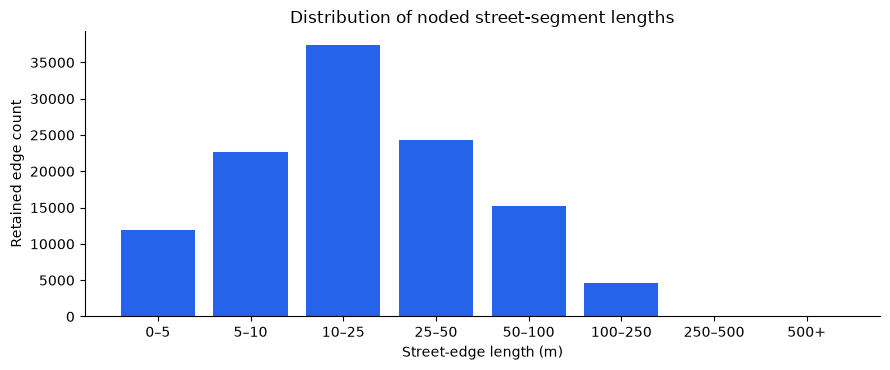

In [11]:
display(pd.DataFrame([
    ['Retained edges', graph_profile['edge_count']],
    ['No OSM highway match', graph_profile['missing_osm_match_edges']],
    ['Missing grade; cost uses flat', graph_profile['missing_grade_edges']],
    ['Segments shorter than 2 m', graph_profile['very_short_edges_under_2m']],
    ['Matched to current cycling route', graph_profile['cycle_matched_edges']],
    ['Bridge/tunnel tag transferred', graph_profile['bridge_tunnel_tagged_edges']],
], columns=['Post-filter check', 'Edge count']))
display(pd.DataFrame({
    'Length (m)': graph_profile['length_m_quantiles'],
    'Absolute grade': graph_profile['absolute_grade_quantiles'],
    'Forward cost / length': graph_profile['cost_factor_quantiles'],
}).round(3))
length_labels = ['0–5','5–10','10–25','25–50','50–100','100–250','250–500','500+']
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(length_labels, graph_profile['length_bin_counts'], color='#2563eb')
ax.set(xlabel='Street-edge length (m)', ylabel='Retained edge count',
       title='Distribution of noded street-segment lengths')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 3. Network benefit

The directed generalized edge cost is defined and demonstrated in Section 2. Shortest paths on that baseline graph are compared with a one-corridor-at-a-time counterfactual. Planned cycling links never enter the baseline.

For each population-weighted origin $o$ and destination class $k$, the counterfactual benefit of candidate $i$ is

$$B_{ik}=\sum_o P_o\,\frac{d_k^0(o)-d_k^i(o)}{250},$$

where distances are generalized metres and 250 m/min is the assumed conversion speed. The benefit is non-negative because the baseline route remains available. Destination classes are **metro entrances**, **train-served Prague stops**, underserved zones, and jobs/services. Metro and train are separate objectives, so a gain to one is not hidden by a closer destination of the other type. The composite screening utility is

$$U_i=0.25\frac{B_{iM}}{\sum_j B_{jM}}+0.25\frac{B_{iR}}{\sum_j B_{jR}}+0.30\frac{B_{iD}}{\sum_j B_{jD}}+0.20\frac{B_{iJ}}{\sum_j B_{jJ}}.$$

Here $M$ is metro, $R$ is rail, $D$ is underserved destinations and $J$ is jobs/services. The score is conditional on the candidate being connected. The previous 50% transport weight is split evenly between metro and train access.

## 4. Connections

Touching source fragments are merged into **717 corridors** so that a fragmented digitized path is evaluated as one possible intervention. A corridor is *not* permanently added to the existing graph. It is tested one at a time as a counterfactual connection between access points on existing edges.

An access record stores the corridor ID, distance along the corridor (`measure_m`), host road `edge_id`, host-edge fraction, host nodes `edge_u`/`edge_v`, physical gap (`connector_m`), access kind and review flags. Three kinds are detected: (1) nearest road to each historical endpoint; (2) exact geometric intersections in the line interior; (3) the shortest road approach within 20 m where the corridor passes near a street. An endpoint more than 20 m from a road is inactive. Interior intersections on tagged bridges/tunnels are skipped. Major-road encounters receive a crossing-review flag.

Access records at almost the same corridor measure, or on the same/adjacent road within 20 m, are deduplicated. A nearby road running parallel to the historical line for more than 30 m does not generate a string of side connections. At least two distinct active access records are required for a corridor to be *routable in the model*. The model may use interior connections even when an original historical endpoint is isolated.

To separate missing links from existing or offset-parallel streets, the model calculates the share of historical length within 10 m of a road and the share running in approximately the same direction within 30 m.

In [12]:
connection_checks = pd.DataFrame([
    ['Merged historical corridors', connections['corridors']],
    ['Both historical endpoints within 20 m of roads', connections['endpoint_edge_valid']],
    ['At least two active model access points', connections['routable_corridors']],
    ['With interior access', connections['with_interior_connections']],
    ['With proximity access', connections['with_proximity_connections']],
    ['Individual proximity access records', connections['proximity_access_points']],
    ['Flagged major-road crossing candidates', connections['major_crossing_candidates']],
], columns=['Connection construction check', 'Count'])
display(connection_checks)
display(table.groupby('screening_class', dropna=False).agg(
    corridors=('corridor_id', 'size'),
    median_length_m=('historical_length_m', 'median'),
    median_access_points=('active_access_points', 'median'),
    median_parallel_fraction=('parallel_existing_road_fraction', 'median')
).round(2))

,Connection construction check,Count
0,Merged historical corridors,717
1,Both historical endpoints within 20 m of roads,51
2,At least two active model access points,144
3,With interior access,141
4,With proximity access,119
5,Individual proximity access records,167
6,Flagged major-road crossing candidates,92


,corridors,median_length_m,median_access_points,median_parallel_fraction
screening_class,,,,
crossing_review,12,635.93,3.0,0.05
other,88,327.01,2.0,0.13
parallel,40,236.03,3.0,0.85
screened_link,4,378.50,3.5,0.23
unconnected,573,255.29,0.0,NaN


### Gap sensitivity

The access algorithm stores endpoint, exact-intersection and proximity records up to 20 m. We hold those records fixed and **reclassify** a record as available only when its connector distance is within the stated scenario threshold. A corridor passes when at least two distinct stored access records remain. The table and curve show how the modeled two-access count changes with the gap assumption.

,maximum_connection_gap_m,corridors_with_two_access_points,share_of_all_corridors,median_active_access_points
0,0,30,0.041841,0.0
1,5,49,0.068340,0.0
2,10,72,0.100418,0.0
3,15,106,0.147838,0.0
4,20,144,0.200837,0.0


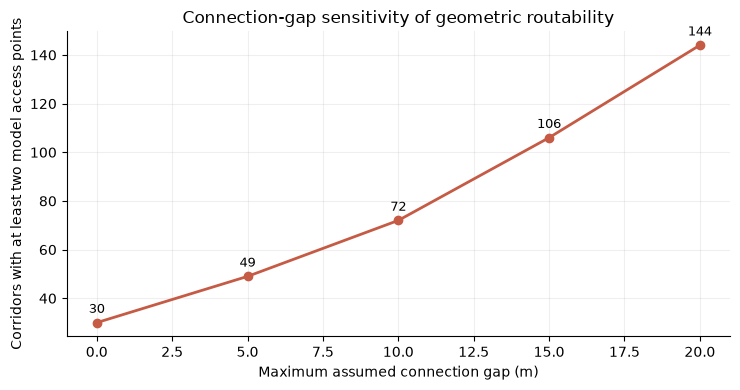

Exact-access scenario: 30 corridors; 20 m scenario: 144; difference: 114.
Difference in modeled two-access corridors across the tested gap scenarios: 114


In [13]:
display(sensitivity)
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(sensitivity.maximum_connection_gap_m,
        sensitivity.corridors_with_two_access_points, marker='o', color='#c55b45', linewidth=2)
for row in sensitivity.itertuples():
    ax.annotate(str(row.corridors_with_two_access_points),
                (row.maximum_connection_gap_m, row.corridors_with_two_access_points),
                xytext=(0, 7), textcoords='offset points', ha='center', fontsize=9)
ax.set(xlabel='Maximum assumed connection gap (m)',
       ylabel='Corridors with at least two model access points',
       title='Connection-gap sensitivity of geometric routability')
ax.spines[['top','right']].set_visible(False)
ax.grid(alpha=.2)
plt.tight_layout(); plt.show()
strict = int(sensitivity.loc[sensitivity.maximum_connection_gap_m.eq(0), 'corridors_with_two_access_points'].iloc[0])
current = int(sensitivity.loc[sensitivity.maximum_connection_gap_m.eq(20), 'corridors_with_two_access_points'].iloc[0])
print(f'Exact-access scenario: {strict} corridors; 20 m scenario: {current}; difference: {current-strict}.')
print('Difference in modeled two-access corridors across the tested gap scenarios:', current-strict)

### Counterfactual route cost

For an origin to enter at access $a$ on road edge $(u,v)$, the model takes the cheaper directed approach via $u$ or $v$, plus the access gap. For access fraction $f$ from $u$:

$$A(o,a)=\min\{d(o,u)+f c_{uv},\ d(o,v)+(1-f)c_{vu}\}+g_a.$$

It then tests travel along the historical corridor between two access measures, with cost $|m_a-m_b|$, and exits to an existing road with another directed edge fraction and gap. The result is compared with the baseline shortest path; the minimum of baseline and all candidate alternatives is used. This implicitly adds temporary access and corridor arcs for scoring. The historical segment is charged at its geometric length. Major-road encounters are gated from the ready shortlist.

### Screening rules

Historical fragments are merged into continuous corridors. Candidate access is detected at endpoint snaps, exact road intersections, and roads within 20 m. Redundant points on the same nearby road are merged. At-grade and grade-separated encounters are treated differently; major-road access is flagged for review. A direction-aware screen identifies historical lines running alongside an existing road as **parallel route options**.

For a missing-link shortlist, the model requires at least a 10% detour reduction and 100 generalized metres saved, no unresolved major-road crossing, no more than 60% within 10 m of roads, and no more than 60% of sampled alignment running parallel within 30 m. All corridors remain visible in the map and table.

,Stage,Count
0,Historical features,1178
1,Merged corridors,717
2,Routable in model,144
3,Crossing-dependent opportunities,12
4,Screened missing links,4
5,Reviewed designs eligible for cost optimization,0


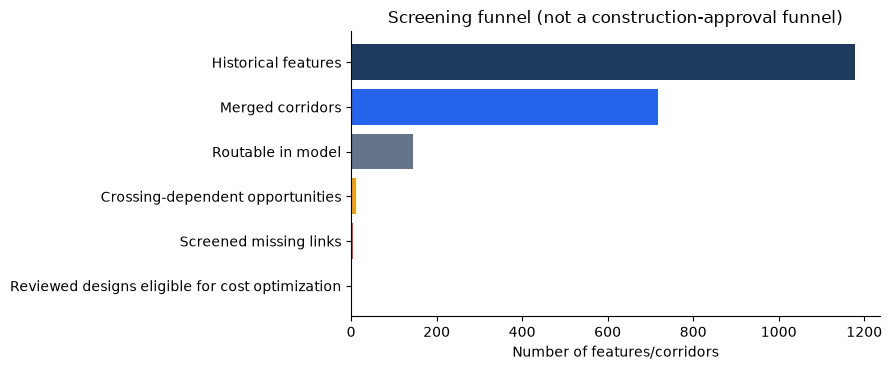

In [14]:
funnel = pd.DataFrame([
    ['Historical features', inventory['historical_paths']['features']],
    ['Merged corridors', connections['corridors']],
    ['Routable in model', connections['routable_corridors']],
    ['Crossing-dependent opportunities', scoring['unresolved_crossing_opportunities']],
    ['Screened missing links', scoring['positive_corridors']],
    ['Reviewed designs eligible for cost optimization', review['eligible_for_optimization']],
], columns=['Stage', 'Count'])
display(funnel)
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.barh(funnel.Stage[::-1], funnel.Count[::-1], color=['#06b6d4','#ef4444','#f59e0b','#64748b','#2563eb','#1e3a5f'])
ax.set(xlabel='Number of features/corridors', title='Screening funnel (not a construction-approval funnel)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

In [15]:
classes = table.screening_class.value_counts().rename_axis('Screening class').reset_index(name='Corridors')
display(classes)
top = table[table.composite_utility.fillna(0).gt(0)].sort_values('composite_utility', ascending=False)
display(top[['corridor_id','screening_class','historical_length_m','parallel_existing_road_fraction',
             'benefit_metro','benefit_train','max_detour_saved_m','composite_utility']].head(12).round(3))

,Screening class,Corridors
0,unconnected,573
1,other,88
2,parallel,40
3,crossing_review,12
4,screened_link,4


,corridor_id,screening_class,historical_length_m,parallel_existing_road_fraction,benefit_metro,benefit_train,max_detour_saved_m,composite_utility
182,183,parallel,229.021,0.783,2536.758,58.040,1306.792,0.200
184,185,parallel,776.393,0.744,270.719,29502.543,2577.797,0.150
233,234,parallel,507.038,0.765,7123.320,0.000,153.242,0.067
378,379,screened_link,353.108,0.000,2228.456,5497.015,2341.245,0.063
429,430,crossing_review,692.803,0.014,1076.345,0.000,1124.619,0.063
394,395,crossing_review,378.358,0.526,638.566,6423.320,350.955,0.061
347,348,screened_link,276.036,0.143,2845.061,532.949,1573.648,0.046
25,26,crossing_review,579.049,0.000,161.237,161.237,301.684,0.039
388,389,crossing_review,167.622,0.000,413.765,0.000,597.266,0.037
395,396,other,330.000,0.000,319.845,2980.376,99.942,0.029


## 5. Results

There are **717 merged corridors** and **144 routable corridors** in the geometric network model. The funnel and ranking above show the updated results when metro and train access are scored separately. Parallel options remain available in the map as a separate category. The cost-constrained portfolio still requires documented manual review before any project is eligible.

Corridor 541 is retained as a major-road crossing example. Corridor 180 largely follows an offset existing road and is classified as a parallel alternative.

The shortlist count follows from the stated detour, crossing and duplication thresholds.

In [16]:
examples = table[table.corridor_id.isin([379,348,541,180])][
    ['corridor_id','screening_class','historical_length_m','active_access_points',
     'parallel_existing_road_fraction','max_detour_saved_m','composite_utility']]
examples.sort_values('corridor_id').round(3)

,corridor_id,screening_class,historical_length_m,active_access_points,parallel_existing_road_fraction,max_detour_saved_m,composite_utility
179,180,parallel,489.390,9,0.653,1735.683,0.019
347,348,screened_link,276.036,4,0.143,1573.648,0.046
378,379,screened_link,353.108,2,0.000,2341.245,0.063
540,541,crossing_review,369.248,2,0.108,365.235,0.023


## 6. Project selection

The project-selection formulation is a 0–1 knapsack,

$$\max_{x_i\in\{0,1\}}\sum_i U_i^{\mathrm{validated}}x_i \quad\text{subject to}\quad \sum_i C_i^{\mathrm{project}}x_i\leq C_{\mathrm{budget}},$$

The model requires validated utility and project cost for each eligible candidate. The manual gate calls for evidenced access, crossing treatment, corridor approval and a documented rescore; no candidate currently qualifies. Selected portfolios are then recalculated on the network to account for overlapping benefits.

The next work package is a connection-likelihood review of shortlisted corridors: road access, crossing conditions, parcel barriers, imagery and local knowledge.

## 7. Future work, limitations and plan

**What the model does not establish.** A geometric road crossing or a gap of at most 20 m is not proof of a usable junction. Street noding can create false turns at bridges or tunnels; midpoint OSM/cycling matches can select an offset road; untagged bicycle access, one-way rules and turn restrictions are incomplete. The historical route is costed at geometric length without measured surface, grade, crossing delay or build cost. The current cost coefficients and 250 m/min conversion are assumptions, not calibrated travel-time or safety estimates. Metro entrances and train GTFS stop points are snapped to street nodes; the train points are not verified station entrances, and station access paths are not modeled separately. The cadastral overlay provides context, not ownership or permission. The two-access count is sensitive to the gap threshold, and the scenario table reclassifies stored records without rerunning spatial matching. The city-part accessibility metric is center-to-center; the benefit metric uses area-allocated population and proxy destinations. This is a mapped-corridor inventory rather than a random sample, so p-values and sampling confidence intervals would not address the main uncertainty. The modeled network contrast is not an observed behavioral or causal effect.

**Next steps.** (1) Audit grade-separated junctions and access/one-way tags; (2) review the shortlisted connection points against imagery, cadastral parcels, crossings and field evidence; (3) estimate connection likelihood or transparent scenarios from reviewed examples; (4) calibrate cycling impedance with observed route/travel data; (5) add project-level cost and safety evidence; (6) rerun the portfolio with network interactions. Until then, the rankings describe conditional potential, not buildable recommendations.

**Project guide.** Data sources, setup and analysis commands are in [`RUNNING.md`](../RUNNING.md). The [interactive map](prague_graph_interactive.html) includes the live ČÚZK cadastral overlay.